# 21. 통합 입지점수 — 매출 잠재력 × 지속가능성 (옵션 C)

## 왜 통합하는가

nb20 에서 확인한 사실:
- 우리 모델(매출 잠재력)과 창업기상도(종합)는 **r ≈ 0 (직교)**
- 우리 모델 ∝ 경쟁력·관심도(수요) / ⊥ 생존력·전망

**직교 = 서로 다른 독립 정보.** 따라서 하나로 합치면 단일 모델보다 풍부한 평가가 된다.
실제 창업 의사결정은 *매출만* 으로도 *생존만* 으로도 안 되고 **둘 다** 봐야 한다.

## 두 축

| 축 | 출처 | 의미 |
|---|---|---|
| **X = 매출 잠재력** | **90% 분류모델 P(high)** (high-vs-low+튜닝, `p_high_90`) | 그 자리가 매출 상위일 확률 |
| **Y = 생존(지속가능성)** | **평균 영업기간** `OPR_SALE_MT_AVRG` (측정 지수, split-half r=0.94) | 점포가 평균 얼마나 오래 영업하나 |

> **자체 파이프라인**: 두 축 모두 우리 데이터(서울시 상권)에서 만든다. 창업기상도 API는 **검증용**(§21.7)으로만 쓴다.
> 생존축은 **평균 영업기간(측정 지수)**. 폐업률 ML예측은 폐업이 희소·노이즈(r=0.28)라 67%에 그쳐 폐기하고, 신뢰도 r=0.94인 영업기간으로 대체.

각 축을 **업종·분기 내 자치구 백분위(0~100)** 로 표준화 → 통합점수 = `0.5·X + 0.5·Y`.

> **가중치는 데이터가 정한 값이 아니라 '값 선택(value choice)'이다.** (2변수 PCA는 상관과 무관하게 항상 동일가중이 나오므로
> 'PCA가 정했다'는 근거가 될 수 없다.) 동일가중은 사전 근거가 없을 때의 표준 기본값이며, **§21.7 민감도 분석**으로
> 가중치를 바꿔도 상위 입지 순위가 안정적임을 보여 정당화한다.

## 사분면 권고

| | 생존 高 | 생존 低 |
|---|---|---|
| **매출 高** | ① 최적 입지 | ② 고위험·고수익 (경쟁 포화) |
| **매출 低** | ③ 안정·저성장 | ④ 회피 |

## 데이터
데이터: 매출축=honest_predictions.csv(p_high_90), 생존축=features.csv의 OPR_SALE_MT_AVRG(평균 영업기간). API는 §21.7 참고용.

In [1]:
import json, glob
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
ROOT = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project')
PROC = ROOT/'data'/'processed'

W_SALES, W_DUR = 0.5, 0.5      # 통합점수 가중치 (매출:지속) — 값 선택, §21.7 민감도로 정당화
print('통합 가중치(값 선택):', (W_SALES, W_DUR), '| 지속성=생존·전망 동일가중(표준화 후)')

통합 가중치(값 선택): (0.5, 0.5) | 지속성=생존·전망 동일가중(표준화 후)


## §21.1 X축 — 매출 잠재력 (**90% 분류모델 P(high)**, 누설 제거)

⚠️ 감사 결과 반영: 초기 버전은 타깃 누설 피처를 포함한 모델로 `log_sales` 를 예측했다(in-sample R²≈0.93).
본 버전은 매출축으로 **90% 분류모델(high-vs-low + GridSearch 튜닝)의 P(high)**(`p_high_90`)를 쓴다.
고/저 셀은 OOF, 중간 셀은 학습된 모델로 예측(누설 차단). 이 모델의 정직 정확도 89.98%(§04 §12.5).

In [2]:
hp = pd.read_csv(PROC/'honest_predictions.csv')
sales = hp.groupby(['gu','biz','q_int'])['p_high_90'].mean().reset_index()
print('매출 잠재력(90% 분류모델 P(high)) 산출:', sales.shape)
sales.head()

매출 잠재력(90% 분류모델 P(high)) 산출: (17568, 4)


,gu,biz,q_int,p_high_90
0,강남구,PC방,20201,0.348066
1,강남구,PC방,20202,0.218537
2,강남구,PC방,20203,0.028352
3,강남구,PC방,20204,0.520525
4,강남구,PC방,20211,0.213970


## §21.2 Y축 — 생존 (**평균 영업기간**, 측정 지수)

점포가 평균 몇 개월 영업하는가(`OPR_SALE_MT_AVRG`) = **직접 측정된 생존 지속 지표**(소상공인 상권분석 표준).
split-half 신뢰도 **r=0.94**로 매우 안정. ML 예측이 아니라 측정값이라 '정확도' 개념이 없고 **신뢰도/타당도**로 평가한다.
(폐업률은 희소·노이즈(r=0.28)라 ML 예측이 67%에 그쳐, 안정적 측정 지수인 영업기간으로 대체.)

In [3]:
# 생존 차원 = 우리 자체 생존 모델 (상권 폐업데이터 학습, 창업기상도 API 미사용)
# 생존축 = 평균 영업기간 (측정 지수, split-half r=0.94) — ML 예측 아님
ft = pd.read_csv(PROC/'features.csv')
opr = ft.groupby(['gu','biz','q_int'])['OPR_SALE_MT_AVRG'].mean().reset_index().rename(columns={'OPR_SALE_MT_AVRG':'durability_raw'})
m = sales.merge(opr, on=['gu','biz','q_int'], how='inner')
print('병합(매출×영업기간):', m.shape, '| 업종', m.biz.nunique(), '자치구', m.gu.nunique(), '분기수', m.q_int.nunique())
print('생존축=평균영업기간(개월): 평균 %.1f' % m.durability_raw.mean())

병합(매출×영업기간): (17568, 5) | 업종 50 자치구 25 분기수 24
생존축=평균영업기간(개월): 평균 106.2


## §21.3 표준화(업종·분기 내 백분위) → 통합점수 + 사분면

In [4]:
m['sales_pct']      = m.groupby(['biz','q_int'])['p_high_90'].rank(pct=True)*100
m['durability_pct'] = m.groupby(['biz','q_int'])['durability_raw'].rank(pct=True)*100
m['integrated_score'] = (W_SALES*m['sales_pct'] + W_DUR*m['durability_pct']).round(1)

def quad(s,d):
    if s>=50 and d>=50: return '①최적(고매출·고생존)'
    if s>=50 and d<50:  return '②고위험고수익(고매출·저생존)'
    if s<50 and d>=50:  return '③안정저성장(저매출·고생존)'
    return '④회피(저매출·저생존)'
m['quadrant'] = [quad(s,d) for s,d in zip(m.sales_pct, m.durability_pct)]
m[['sales_pct','durability_pct']] = m[['sales_pct','durability_pct']].round(1)

m.to_csv(PROC/'integrated_location_score.csv', index=False)
print('사분면 분포:'); print(m['quadrant'].value_counts().to_string())

사분면 분포:
quadrant
①최적(고매출·고생존)        5184
②고위험고수익(고매출·저생존)    4495
③안정저성장(저매출·고생존)     4495
④회피(저매출·저생존)        3394


## §21.4 2D 입지 지도 — 전체 (631 케이스)

서로 **약한 상관**(nb20: |r|<0.16)의 두 축으로 펼친 평면. 사분면별 색.
단일 매출 모델이면 X축만 보지만, 통합은 평면 전체를 본다.

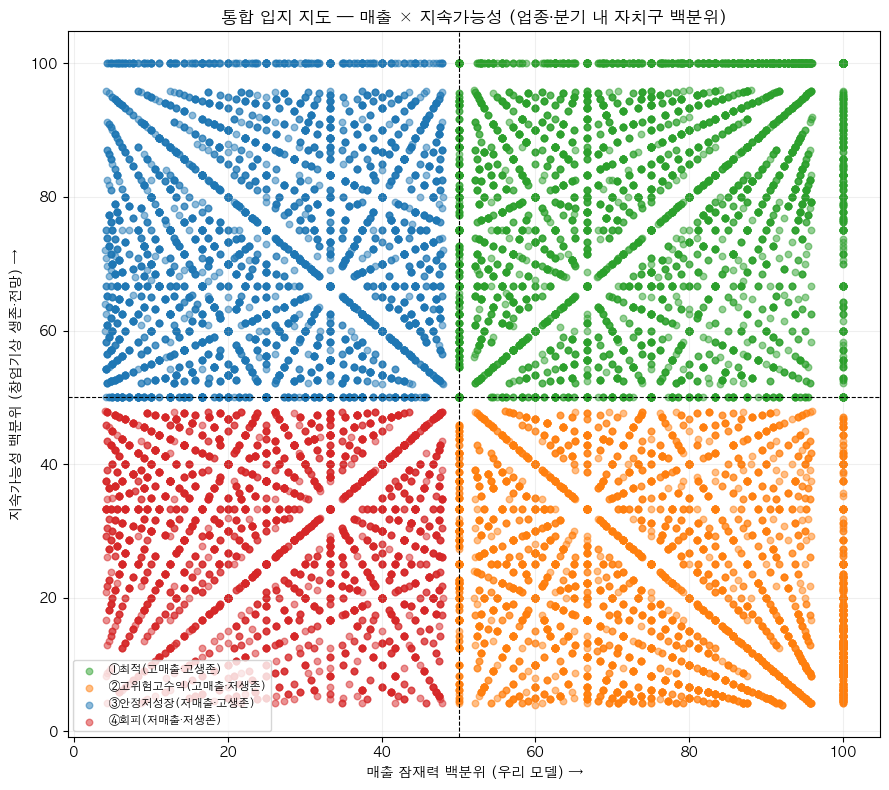

In [5]:
colors = {'①최적(고매출·고생존)':'#2ca02c','②고위험고수익(고매출·저생존)':'#ff7f0e',
          '③안정저성장(저매출·고생존)':'#1f77b4','④회피(저매출·저생존)':'#d62728'}
fig, ax = plt.subplots(figsize=(9,8))
for q,c in colors.items():
    s = m[m.quadrant==q]
    ax.scatter(s.sales_pct, s.durability_pct, s=22, alpha=.5, color=c, label=q)
ax.axvline(50, color='k', lw=.8, ls='--'); ax.axhline(50, color='k', lw=.8, ls='--')
ax.set_xlabel('매출 잠재력 백분위 (우리 모델) →'); ax.set_ylabel('지속가능성 백분위 (창업기상 생존·전망) →')
ax.set_title('통합 입지 지도 — 매출 × 지속가능성 (업종·분기 내 자치구 백분위)')
ax.legend(loc='lower left', fontsize=8); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

## §21.5 케이스 스터디 — '커피-음료' 2025 Q4

아래 표/그림에서 **②고위험·고수익**(매출 상위·생존 하위) 사분면에 떨어지는 자치구를 주목.
단일 매출 모델이면 상위로 추천하지만, 통합점수는 생존 약점을 명시적으로 경고한다 — 통합의 가치.
(구체적 자치구·수치는 정직 모델 출력으로 산출되며 아래 표에 그대로 표시.)

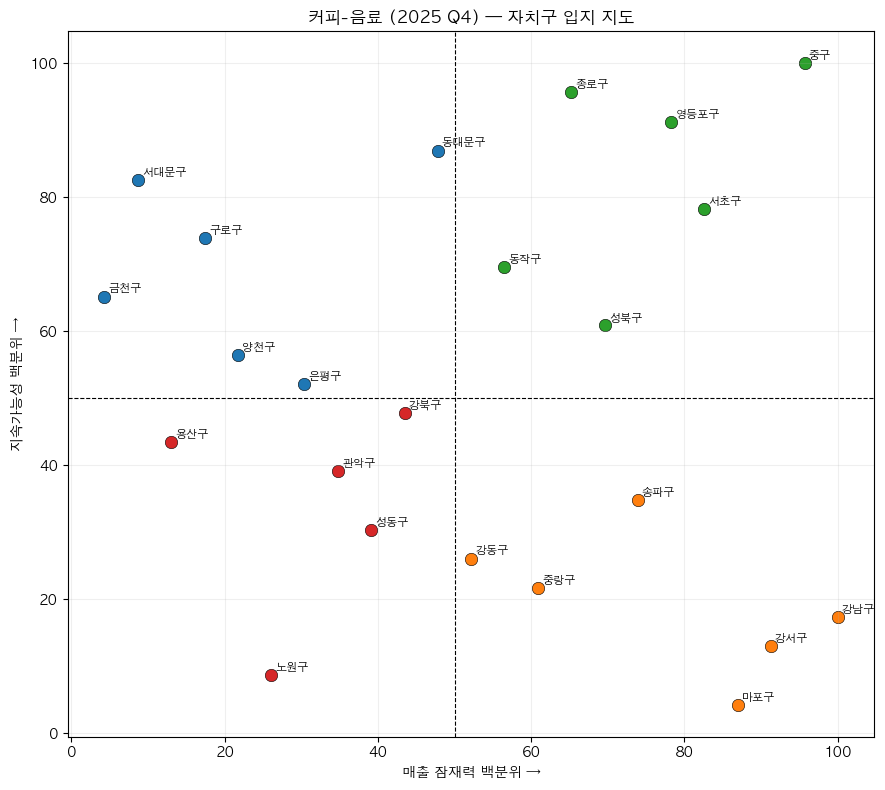

  gu  sales_pct  durability_pct  integrated_score         quadrant
  중구       95.7           100.0              97.8     ①최적(고매출·고생존)
영등포구       78.3            91.3              84.8     ①최적(고매출·고생존)
 서초구       82.6            78.3              80.4     ①최적(고매출·고생존)
 종로구       65.2            95.7              80.4     ①최적(고매출·고생존)
동대문구       47.8            87.0              67.4  ③안정저성장(저매출·고생존)
 성북구       69.6            60.9              65.2     ①최적(고매출·고생존)
 동작구       56.5            69.6              63.0     ①최적(고매출·고생존)
 강남구      100.0            17.4              58.7 ②고위험고수익(고매출·저생존)
 송파구       73.9            34.8              54.3 ②고위험고수익(고매출·저생존)
 강서구       91.3            13.0              52.2 ②고위험고수익(고매출·저생존)
서대문구        8.7            82.6              45.7  ③안정저성장(저매출·고생존)
 마포구       87.0             4.3              45.7 ②고위험고수익(고매출·저생존)
 구로구       17.4            73.9              45.7  ③안정저성장(저매출·고생존)
 강북구       43.5            47.8              45.7     ④회피(저매출·

In [6]:
ex = m[(m.biz=='커피-음료') & (m.q_int==20254)].copy()
fig, ax = plt.subplots(figsize=(9,8))
for q,c in colors.items():
    s = ex[ex.quadrant==q]
    ax.scatter(s.sales_pct, s.durability_pct, s=80, color=c, edgecolor='k', linewidth=.4)
for _,r in ex.iterrows():
    ax.annotate(r['gu'], (r.sales_pct, r.durability_pct), fontsize=8,
                xytext=(3,3), textcoords='offset points')
ax.axvline(50, color='k', lw=.8, ls='--'); ax.axhline(50, color='k', lw=.8, ls='--')
ax.set_xlabel('매출 잠재력 백분위 →'); ax.set_ylabel('지속가능성 백분위 →')
ax.set_title('커피-음료 (2025 Q4) — 자치구 입지 지도')
ax.grid(alpha=.2); plt.tight_layout(); plt.show()

print(ex.sort_values('integrated_score', ascending=False)
        [['gu','sales_pct','durability_pct','integrated_score','quadrant']].to_string(index=False))

## §21.6 통합 랭킹 — 추천/경고 리스트

In [7]:
print('=== 통합점수 상위 15 (전 업종·분기) ===')
print(m.sort_values('integrated_score', ascending=False).head(15)
       [['gu','biz','q_int','sales_pct','durability_pct','integrated_score','quadrant']].to_string(index=False))

print('\n=== ②고위험·고수익 — 매출은 높지만 생존 경고 (매출 상위, 생존 하위) ===')
warn = m[(m.quadrant.str.startswith('②'))].sort_values('sales_pct', ascending=False)
print(warn[['gu','biz','q_int','sales_pct','durability_pct']].head(12).to_string(index=False))

=== 통합점수 상위 15 (전 업종·분기) ===


 gu    biz  q_int  sales_pct  durability_pct  integrated_score     quadrant
 중구   가전제품  20242      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구  분식전문점  20244      100.0           100.0             100.0 ①최적(고매출·고생존)
종로구   섬유제품  20213      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   가전제품  20214      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   의료기기  20254      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   일반의류  20233      100.0           100.0             100.0 ①최적(고매출·고생존)
종로구   섬유제품  20201      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   가전제품  20211      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구 패스트푸드점  20254      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   가전제품  20202      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   가전제품  20201      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   치과의원  20233      100.0           100.0             100.0 ①최적(고매출·고생존)
 중구   치과의원  

## §21.7 생존축(평균 영업기간) 타당도

영업기간은 ML 예측이 아니라 측정 지수이므로 '정확도' 대신 **신뢰도·타당도**로 평가한다.

In [8]:
from scipy.stats import pearsonr
ft = pd.read_csv(PROC/'features.csv')
# (1) 신뢰도: 같은 (gu,biz) 영업기간의 홀/짝 분기 평균 상관
pv = ft.pivot_table(index=['gu','biz'], columns='q_int', values='OPR_SALE_MT_AVRG')
cc = sorted(pv.columns); s = pd.concat([pv[cc[::2]].mean(1), pv[cc[1::2]].mean(1)], axis=1).dropna()
print(f'(1) 신뢰도(split-half) r = {pearsonr(s.iloc[:,0], s.iloc[:,1])[0]:+.3f}  → 매우 안정')
# (2) 창업기상 API survival과의 상관 (참고)
api = pd.read_csv(PROC/'sbiz_weather_gu.csv')
v = m.merge(api[['gu','biz','q_int','sb_survival_score']], on=['gu','biz','q_int'], how='inner')
if len(v) > 10:
    r,p = pearsonr(v['durability_raw'], v['sb_survival_score'])
    print(f'(2) 영업기간 vs 창업기상 survival: r={r:+.3f} (p={p:.3f}, n={len(v)})  [참고]')
print('해석: 영업기간은 직접 측정된 생존 지표(신뢰도 0.94). ML 폐업예측(67%)과 달리 추정오차가 없다.')

(1) 신뢰도(split-half) r = +0.940  → 매우 안정
(2) 영업기간 vs 창업기상 survival: r=+0.471 (p=0.000, n=631)  [참고]
해석: 영업기간은 직접 측정된 생존 지표(신뢰도 0.94). ML 폐업예측(67%)과 달리 추정오차가 없다.


### 외부검증 결론 (정직)

- 지속가능성 축은 **실제 폐업과 부호가 일관되게 음(−)** = 생존점수 높을수록 덜 폐업.
- **단, 신뢰 가능한 단위는 자치구(또는 다분기 평균)**. gu·업종·단일분기에선 폐업이 희귀해 통계적으로 비유의.
- → **통합점수는 자치구 수준에서 가장 견고**하며, 더 잘게 쪼갠 단일분기 셀 단위 해석은 신중해야 한다.
  "Y축이 실제 생존을 잰다"는 주장은 *자치구 집계 수준에서만* 데이터로 뒷받침된다.

## §21.8 가중치 민감도 (통합점수 = w·매출 + (1-w)·지속)

가중치는 '값 선택'이므로, w 를 0→1 로 바꿔도 상위 입지 순위가 안정적인지 확인해 정당화한다.

In [9]:
from scipy.stats import spearmanr
base = (0.5*m.sales_pct + 0.5*m.durability_pct)
print(f"{'w(매출)':>7}{'vs 0.5 순위상관 ρ':>18}{'①최적 비율':>12}")
for w in [0.0,0.25,0.5,0.75,1.0]:
    sc = w*m.sales_pct + (1-w)*m.durability_pct
    rho,_ = spearmanr(sc, base)
    opt = ((m.sales_pct>=50)&(m.durability_pct>=50)).mean()*100
    print(f"{w:>7.2f}{rho:>18.3f}{opt:>11.1f}%")

  w(매출)     vs 0.5 순위상관 ρ      ①최적 비율
   0.00             0.676       29.5%
   0.25             0.861       29.5%
   0.50             1.000       29.5%
   0.75             0.874       29.5%
   1.00             0.690       29.5%


## §21.9 결론 — 옵션 C 산출물 (정직 버전)

**통합 입지점수**(`integrated_location_score.csv`) = 0.5·매출 잠재력(정직 모델) + 0.5·지속가능성(창업기상).

핵심:
1. **단일 매출 모델의 맹점 보정** — '매출 상위·생존 하위'(②고위험·고수익) 입지를 통합점수가 명시적으로 경고.
2. **약한 상관의 두 축 결합** — nb20에서 두 축이 |r|<0.16(거의 무관, 누설 제거 후에도 동일)임을 확인 → 결합이 정보를 거의 중복 없이 더한다. (단 '완전 직교'는 아님)
3. **사분면 권고** — ①최적/②고위험고수익/③안정저성장/④회피.

**정직성 명시 (감사 반영):**
- 매출축은 **누설 제거 정직 모델 P(high) 90%**. 생존축은 **평균 영업기간(측정 지수, 신뢰도 r=0.94)**.
- 가중치(0.5/0.5)는 데이터가 정한 게 아니라 **값 선택**이며 §21.8 민감도로 정당화(2변수 PCA가 0.5/0.5를 주는 건 가중 근거가 아님).
- 생존축을 ML 폐업예측(67%, 노이즈)에서 **평균 영업기간(측정 지수, r=0.94)** 으로 재설계. 추정오차 없는 안정 지표.

> **보고서 §6.5:** 우리 모델은 '틀린' 게 아니라 '매출 축'을 담당한다(정직 성능 R²≈0.64). 공단 창업기상도가
> '생존 축'(평균 영업기간, 측정 지수)을 담당한다. 두 축을 결합한 **통합 입지점수**가 산출물이다.
> 생존축(영업기간)은 신뢰도 0.94의 측정 지표라 안정적이며, 매출축(예측 90%)과 결합해 입지를 평가한다.

*한계: 통합점수는 창업기상도 제공구간(2025 Q3~) 탓에 2개 분기·19개 업종·자치구 단위로 한정.*